In [2]:
"""
Atomic fountain ballistics: sensitivity to launch velocity error.

Geometry:
- Atoms launched vertically from MOT location (z = 0) with initial velocity v0.
- State preparation and state analysis both occur at z = z_int = 0.80 m
  (atoms pass through this height twice: once on the way up, once on the way down).
- Apex height: h = v0^2 / (2g)
- Time to reach height z (going up):   t_up   = (v0 - sqrt(v0^2 - 2 g z)) / g
- Time to reach height z (coming down): t_down = (v0 + sqrt(v0^2 - 2 g z)) / g
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------- Constants & nominal parameters ----------------
g = 9.80665                  # m/s^2
v_track = 0.20             # m/s, retroreflector track speed
v0 = 16 * v_track * np.sqrt(2)   # atomic launch velocity = 2 * mirror velocity
                             # (Doppler: moving retroreflector doubles the shift)
# Note: if your geometry gives a different ratio, change the factor of 2.
print(f"Nominal launch velocity v0 = {v0:.4f} m/s")

z_int = .9                # m, height of state prep / analysis region

# ---------------- Helper functions ----------------
def apex_height(v0):
    return v0**2 / (2 * g)

def apex_time(v0):
    return v0 / g

def t_cross(v0, z):
    """Times atoms cross height z on the way up and on the way down.
    Returns (t_up, t_down).
    - If z > apex: both NaN (atoms never reach z).
    - If 0 <= z <= apex: two positive crossings (up and down).
    - If z < 0: only one physical crossing (down, after apex). t_up set to NaN.
    """
    v0 = np.asarray(v0, dtype=float)
    z = np.asarray(z, dtype=float)
    disc = v0**2 - 2 * g * z
    disc = np.where(disc < 0, np.nan, disc)  # never reaches z
    s = np.sqrt(disc)
    t_up = (v0 - s) / g
    t_down = (v0 + s) / g
    # Mask unphysical (negative-time) "up" crossings when z < 0
    t_up = np.where(t_up < 0, np.nan, t_up)
    return t_up, t_down

# ---------------- Sanity check vs. your numbers ----------------
h_apex = apex_height(v0)
t_apex = apex_time(v0)
t_up, t_down = t_cross(v0, z_int)
print(f"Apex height: {h_apex*1000:.1f} mm  (you quoted 1024 mm)")
print(f"Time to apex: {t_apex*1000:.1f} ms  (you quoted 457 ms)")
print(f"State prep crossing (up):     t = {t_up*1000:.2f} ms")
print(f"State analysis crossing (down): t = {t_down*1000:.2f} ms")
print(f"Interrogation time (down - up): {(t_down - t_up)*1000:.2f} ms")

# ---------------- Sensitivity to launch velocity error ----------------
# Sweep fractional velocity error from -2% to +2%
frac_err = np.linspace(-0.0, 0.02, 401)
v0_arr = v0 * (1 + frac_err)
t_up_arr, t_down_arr = t_cross(v0_arr, z_int)
T_int = t_down_arr - t_up_arr  # interrogation time (Ramsey-like)

# Convert fractional velocity error to absolute track velocity error (mm/s)
track_err_mms = frac_err * v_track * 1000
h_apex_arr = apex_height(v0_arr)
# Reference (nominal) values
t_up0, t_down0 = t_cross(v0, z_int)



Nominal launch velocity v0 = 4.5255 m/s
Apex height: 1044.2 mm  (you quoted 1024 mm)
Time to apex: 461.5 ms  (you quoted 457 ms)
State prep crossing (up):     t = 289.99 ms
State analysis crossing (down): t = 632.95 ms
Interrogation time (down - up): 342.97 ms


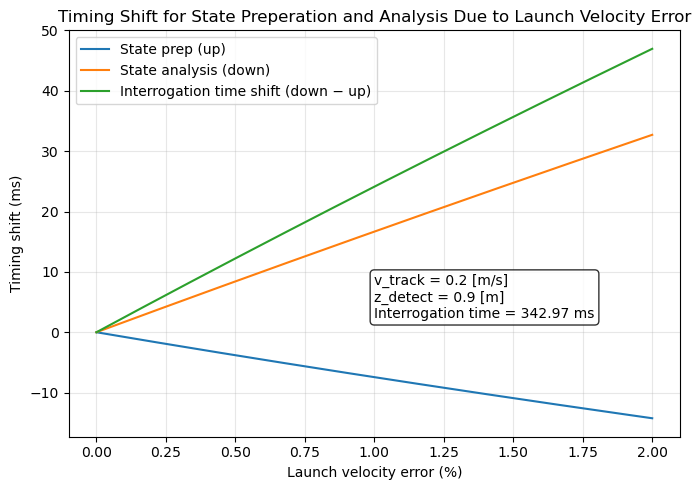

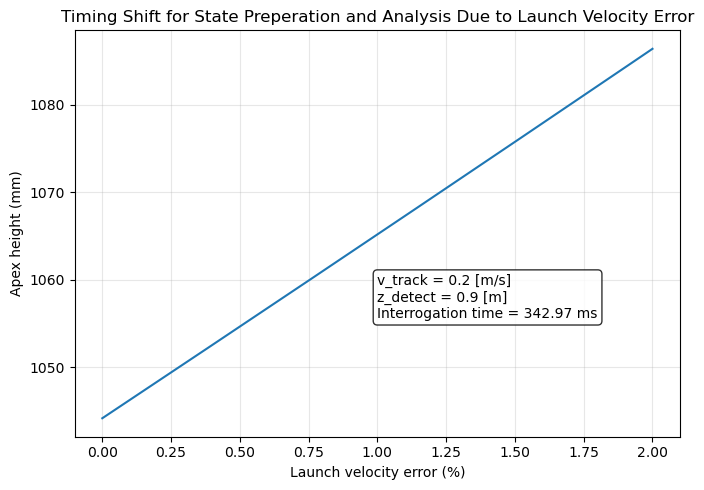

In [3]:
plt.figure(figsize=(7, 5))
mask = frac_err >= 0
plt.plot(frac_err * 100, (t_up_arr - t_up0) * 1000, label='State prep (up)')
plt.plot(frac_err * 100, (t_down_arr - t_down0) * 1000, label='State analysis (down)')
plt.plot(frac_err * 100, ((t_down_arr - t_up_arr) - (t_down0 - t_up0)) * 1000, label='Interrogation time shift (down − up)')
plt.text(0.5, 0.4, f'v_track = {v_track} [m/s]\nz_detect = {z_int} [m]\nInterrogation time = {(t_down - t_up)*1000:.2f} ms',
         transform=plt.gca().transAxes, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Launch velocity error (%)')
plt.ylabel('Timing shift (ms)')
plt.title(f'Timing Shift for State Preperation and Analysis Due to Launch Velocity Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(frac_err * 100, (h_apex_arr) * 1000)
plt.text(0.5, 0.4, f'v_track = {v_track} [m/s]\nz_detect = {z_int} [m]\nInterrogation time = {(t_down - t_up)*1000:.2f} ms',
         transform=plt.gca().transAxes, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Launch velocity error (%)')
plt.ylabel('Apex height (mm)')
plt.title(f'Timing Shift for State Preperation and Analysis Due to Launch Velocity Error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()